In [1]:
from phasic import (
    Graph, Property, StateIndexer, with_ipv, 
    cache, configure, clear_caches
)
from phasic.distributed_scc import compute_scc_levels
import numpy as np
import matplotlib.pyplot as plt
from vscodenb import set_vscode_theme
set_vscode_theme()

## SMC'

Joint prob of tons at two loci conditioned on **_at most_** one recombination event.

In [2]:
nr_samples = 2
indexer = StateIndexer(
    "nr_recs",
    "trash",    
    descendants=[
    Property('loc1', max_value=nr_samples),
    Property('loc2', max_value=nr_samples),
])
initial = [0] * indexer.state_length
initial[indexer.props_to_index(loc1=1, loc2=1)] = nr_samples
initial[indexer.nr_recs] = 0
initial[indexer.trash] = 0

# for i in range(indexer.descendants.state_length):
#     print(indexer.i2p(i))

def two_locus_arg(state, absorbing=[], reclim=None, indexer=None):

    transitions = []
    if state[:-2].sum() <= 1: ### NB: -2 back to avoid slots............
        return transitions

    if state[indexer.trash] == 1:
        trash_sister = state.copy()
        trash_sister[indexer.trash] = 0
        return [[trash_sister, [1, 1]]]

    assert state[indexer.trash] == 0

    if reclim is not None and state[indexer.nr_recs] > reclim[1]:
        trash_sister = state.copy()
        trash_sister[indexer.trash] = 1
        return [[trash_sister, [0, 1.0]]]

    for i in range(indexer.descendants.state_length):
        if state[i] == 0:
            continue
        pi = indexer.index_to_props(i)
        # Coalescence
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0:
                continue
            pj = indexer.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            child[indexer.nr_recs] = state[indexer.nr_recs] # pass on nr recorded rec events
            loc1 = pi.descendants.loc1 + pj.descendants.loc1
            loc2 = pi.descendants.loc2 + pj.descendants.loc2
            if loc1 <= nr_samples and loc2 <= nr_samples:
                child[indexer.props_to_index(loc1=loc1, loc2=loc2)] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            print(tuple(child[:-2]), absorbing)
            if absorbing and tuple(child[:-2].tolist()) in absorbing and reclim is not None and child[indexer.nr_recs] < reclim[0]:
                trash_sister = state.copy()
                trash_sister[indexer.trash] = 1
                transitions.append([trash_sister, [rate, 0]])
            else:
                print('coal', absorbing, tuple(child[:-2].tolist()), child[indexer.nr_recs], reclim)
                transitions.append([child, [rate, 0]])

        # Recombination — this is what creates cycles
        if state[i] > 0 and pi.descendants.loc1 > 0 and pi.descendants.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.props_to_index(loc1=pi.descendants.loc1, loc2=0)] += 1
            child[indexer.props_to_index(loc1=0, loc2=pi.descendants.loc2)] += 1
            if reclim and child[indexer.nr_recs] <= reclim[1]:
                child[indexer.nr_recs] = state[indexer.nr_recs] + 1 # add one to nr of recorded rec events
            if absorbing and tuple(child[:-2].tolist()) in absorbing and reclim is not None and child[indexer.nr_recs] < reclim[0]:   ### NB: -2 back to avoid slots............
                trash_sister = state.copy()
                trash_sister[indexer.trash] = 1
                transitions.append([trash_sister, [0, 1.0]])
            else:
                transitions.append([child, [0, 1.0]])
                
    return transitions

(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) []
coal [] (0, 0, 0, 0, 0, 0, 0, 0, 1) 0 None
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(2), np.int32(0), np.int32(0), np.int32(0), np.int32(0)) []
coal [] (0, 0, 0, 0, 2, 0, 0, 0, 0) 0 None
(np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0)) []
coal [] (0, 0, 0, 1, 0, 1, 0, 0, 0) 0 None
(np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0)) []
coal [] (0, 1, 0, 0, 0, 0, 0, 1, 0) 0 None
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) []
coal [] (0, 0, 0, 0, 0, 0, 0, 0, 1) 0 None
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) []
coal [] (0, 0, 0, 0, 0, 0, 0, 0, 1) 0 None
(np.int32(0), np

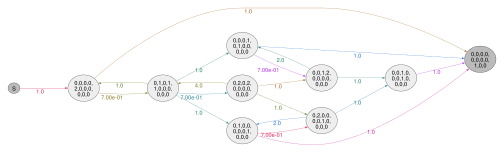

In [3]:
arg_graph = Graph(two_locus_arg, ipv=initial, indexer=indexer)
arg_graph.update_weights([1, 0.7])
print(arg_graph.vertices_length())
arg_graph.plot(ranksep=3, fontsize=25)

[(0, 0, 0, 0, 0, 0, 0, 0, 1)]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) [(0, 0, 0, 0, 0, 0, 0, 0, 1)]
coal [(0, 0, 0, 0, 0, 0, 0, 0, 1)] (0, 0, 0, 0, 0, 0, 0, 0, 1) 0 [0, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(2), np.int32(0), np.int32(0), np.int32(0), np.int32(0)) [(0, 0, 0, 0, 0, 0, 0, 0, 1)]
coal [(0, 0, 0, 0, 0, 0, 0, 0, 1)] (0, 0, 0, 0, 2, 0, 0, 0, 0) 1 [0, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0)) [(0, 0, 0, 0, 0, 0, 0, 0, 1)]
coal [(0, 0, 0, 0, 0, 0, 0, 0, 1)] (0, 0, 0, 1, 0, 1, 0, 0, 0) 1 [0, 1]
(np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0)) [(0, 0, 0, 0, 0, 0, 0, 0, 1)]
coal [(0, 0, 0, 0, 0, 0, 0, 0, 1)] (0, 1, 0, 0, 0, 0, 0, 1, 0) 1 [0, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0)

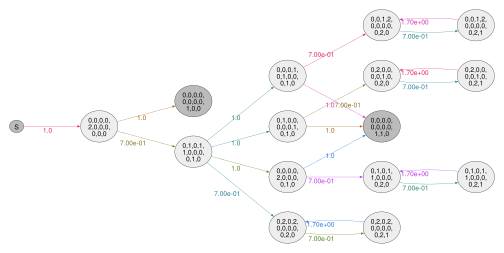

In [4]:
absorbing = []
for vertex in arg_graph.vertices():
    if not vertex.edges_length():
        absorbing.append(tuple(vertex.state()[:-2].tolist())) ### NB: -2 back to avoid slots............
print(absorbing)

at_most_one_rec_graph = Graph(two_locus_arg, ipv=initial, absorbing=absorbing, reclim=[0, 1], indexer=indexer)
at_most_one_rec_graph.update_weights([1, 0.7])
print(at_most_one_rec_graph.vertices_length())
at_most_one_rec_graph.plot(ranksep=3, fontsize=25)

(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) []
coal [] (0, 0, 0, 0, 0, 0, 0, 0, 1) 0 [1, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(2), np.int32(0), np.int32(0), np.int32(0), np.int32(0)) []
coal [] (0, 0, 0, 0, 2, 0, 0, 0, 0) 1 [1, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0)) []
coal [] (0, 0, 0, 1, 0, 1, 0, 0, 0) 1 [1, 1]
(np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0)) []
coal [] (0, 1, 0, 0, 0, 0, 0, 1, 0) 1 [1, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) []
coal [] (0, 0, 0, 0, 0, 0, 0, 0, 1) 1 [1, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) []
coal [] (0, 0, 0, 0, 0, 0, 0, 0, 1) 1 [1, 1]
(np.

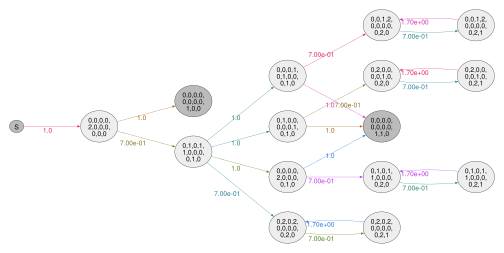

In [5]:
absorbing = []
for vertex in at_most_one_rec_graph.vertices():
    if not vertex.edges_length():
        absorbing.append(tuple(vertex.state()))

exactly_one_rec_graph = Graph(two_locus_arg, ipv=initial, reclim=[1, 1], indexer=indexer)
exactly_one_rec_graph.update_weights([1, 0.7])
print(exactly_one_rec_graph.vertices_length())
exactly_one_rec_graph.plot(ranksep=3, fontsize=25)

In [6]:
jp_graph = at_most_one_rec_graph.joint_prob_graph(reward_limit=1)
jp_graph.plot()

Graph has too many nodes (348). Please set max_nodes to a higher value.


In [7]:
jp_graph.joint_prob_table().head()

,loc1_0,loc1_1,loc1_2,loc2_0,loc2_1,loc2_2,prob
t_vertex_index,,,,,,,
2,0,0,0,0,0,0,0.166667
14,0,1,0,0,0,0,0.055556
16,0,0,0,0,1,0,0.055556
17,0,0,0,0,0,0,0.008333
46,0,1,0,0,1,0,0.037037


Joint prob of tons at two loci conditioned on **_exactly_** one recombination event.

(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1)) [(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0)), (np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0))]
coal [(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0)), (np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0))] (0, 0, 0, 0, 0, 0, 0, 0, 1) 0 [1, 1]
(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(2), np.int32(0), np.int32(0), np.int32(0), np.int32(0)) [(np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32

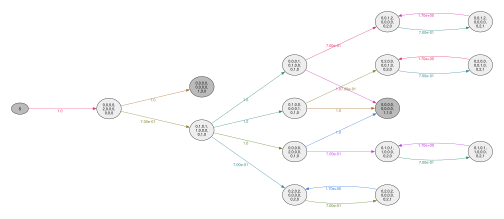

In [8]:
exactly_one_rec_graph = Graph(two_locus_arg, ipv=initial, reclim=[1, 1], absorbing=absorbing, indexer=indexer)
exactly_one_rec_graph.update_weights([1, 0.7])
print(exactly_one_rec_graph.vertices_length())
exactly_one_rec_graph.plot(ranksep=3)

In [9]:
exactly_one_rec_graph.expectation()

inf

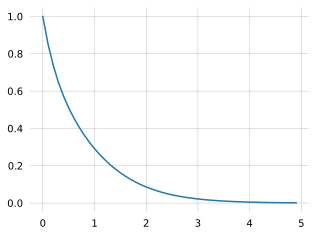

In [10]:
r = np.arange(0, 5, 0.1)
plt.plot(r, exactly_one_rec_graph.pdf(r)) ;